## Codes to do various tiny things

In [ ]:
## Saving a tuple using pickle!
import random
import pickle
rng = random.Random()
rng.seed(42)
state = rng.getstate()

with open('state_1.pkl', 'wb') as f:
    pickle.dump(state, f)

with open('state_1.pkl', 'rb') as f:
    state_1 = pickle.load(f)

print(state_1)


In [ ]:
## Saving the matrices into .csv files
import numpy as np
from numpy import ndarray

rho = np.load('Data_1/rho1001.npy')
rho = ndarray.round(rho,2)
np.savetxt('Text/rho1001.csv',rho, fmt='%.2f' , delimiter = ',') 
print(rho)

In [ ]:
## How to do a Bar plot!
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C', 'D']
values = [10, 15, 7, 12]

# Create the bar chart
plt.bar(categories, values, color='skyblue')

# Add labels and title
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Chart Example')

# Display the chart
plt.show()

In [ ]:
## How to plot a color mesh
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, Z, shading='gouraud', cmap='viridis')
fig.colorbar(mesh)
plt.show()

In [ ]:
## mesh plot with semilog axes!
import matplotlib.pyplot as plt
import numpy as np

# Sample data
a = np.log10(0.5)
b = np.log10(128)
x = np.logspace(a, b, 100)
y = np.linspace(0, 50, 51)
#y = (1,5,10,15,20,25,30,35,40,45,50)
z = np.random.rand(51, 100)

# Create the figure and axes
fig, ax = plt.subplots()

# Plot the pcolormesh
mesh = ax.pcolormesh(x, y, z, shading='gouraud')

# Set x-axis to logarithmic scale
ax.set_xscale('log')

# Add a colorbar
fig.colorbar(mesh)

# Set labels and title
ax.set_xlabel('X-axis (log scale)')
ax.set_ylabel('Y-axis')
ax.set_title('Semilog pcolormesh Plot')

# Show the plot
plt.show()

In [ ]:
## How to print to a file
import numpy as np
with open('output.txt', 'w') as f:
    for i in range(13):
        A = np.load(f'Data_2/Ham{i+1}000.npy')
        print(f'Ham{i+1}000 loaded!', file=f)

with open('output.txt', 'a') as f:
    print('Meet you again', file=f)


In [ ]:
## MG series using reservoirpy module!
from reservoirpy.datasets import mackey_glass
import matplotlib.pyplot as plt
import numpy as np

# Generate 15000 timesteps with default parameters (tau=17, a=0.2, b=0.1, n=10)
mg_series_reservoirpy = mackey_glass(15000, tau=17, a=0.2, b=0.1, n=10)
a = np.max(mg_series_reservoirpy)
b = np.min(mg_series_reservoirpy)
mg_series_reservoirpy = mg_series_reservoirpy - b
mg_series_reservoirpy = mg_series_reservoirpy/(a-b)
mg_series_reservoirpy = mg_series_reservoirpy[3000:]

plt.figure(figsize=(10, 5))
plt.plot(mg_series_reservoirpy)
plt.title('Mackey-Glass Time Series (from reservoirpy)')
plt.xlabel('Time Step')
plt.ylabel('x(t)')
plt.xlim(9500,10100)
plt.grid(True)
plt.show()

In [ ]:
## Class object!
class Dog:
    def __init__(self, name, breed):
        self.name = name  # Attribute
        self.breed = breed # Attribute

    def bark(self):
        print(f"{self.name} says Woof!") # Method

# Creating objects (instances) of the Dog class
my_dog = Dog("Buddy", "Golden Retriever")
another_dog = Dog("Lucy", "Labrador")

# Accessing attributes
print(my_dog.name)
print(another_dog.breed)

# Calling methods
my_dog.bark()
another_dog.bark()

In [ ]:
## How to use enumerate!
A = [5,6,4,2,3]
print([j for i,j in enumerate(A)])

In [ ]:
## How to find the index of an element in a list, array, or something similar.
import numpy as np

arr = np.array([10, 20, 30, 40, 50])

# Find where the value is 30
index = np.where(arr == 30)

print(index[0]) # Output: [2]

## Codes used for ploting the reproduced results of the QRC paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V = [1,2,5,10,25,50]
n = [2,5,10,15,20]
TAU = [1,2,4,8,16,32,64,128]

figure, axes = plt.subplots(2,3,figsize=(10,10))
LINE = []
for tau in [1,2,4,8,16,32,64,128]:
    MEAN = np.load(f'NARMA/Random_input/Results/MEAN_{tau}.npy')
    STD = np.load(f'NARMA/Random_input/Results/STD_{tau}.npy')
    
    for i in range(5):
        line, = axes[i//3,i%3].loglog(V,MEAN[:,i],marker='s',fillstyle='none', label=f'tau = {tau}')
        axes[i//3,i%3].errorbar(V,MEAN[:,i],yerr=STD[:,i],capsize=5)
        axes[i//3,i%3].set_title(f'NARMA{n[i]}')
    LINE += [line,]
axes[1,2].legend(handles=LINE, loc='center', frameon='False')
axes[1,2].set_xticks([])
axes[1,2].set_yticks([])
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)
axes[1,2].spines['bottom'].set_visible(False)
axes[1,2].spines['left'].set_visible(False)

In [ ]:
## Timer task results
import numpy as np
import matplotlib.pyplot as plt

T = np.linspace(401,800,400)
s_test = np.load('Timer_task/s.npy')
y = np.load('Timer_task/y.npy')
Tau_timer = [5,10,15,20,25,30]

figure, axes = plt.subplots(8,1,figsize=(40,30))
line0, = axes[0].plot(T,s_test,color='y',label='input',linewidth='10')
for i in range(1,7):
        line1, = axes[i].plot(T,y[:,i-1],color='k',label='target',linewidth='10')
        axes[i].axvline(x=500,linestyle='--')
        axes[i].set_title(f'tau_timer = {Tau_timer[i-1]}')

LINE=[line0,line1,]
for V in [1,2,5,10]:
    y_out = np.load(f'Timer_task/Version1/y_out_{V}.npy')
    for i in range(1,7):
        line, = axes[i].plot(T,y_out[:,i-1],label=f'V={V}',linewidth='10')
    LINE += [line,]

for i in range(7):
     axes[i].set_xlim(490,540)

axes[7].legend(handles=LINE,loc='center',frameon='False')
axes[7].set_xticks([])
axes[7].set_yticks([])
axes[7].spines['top'].set_visible(False)
axes[7].spines['right'].set_visible(False)
axes[7].spines['bottom'].set_visible(False)
axes[7].spines['left'].set_visible(False)

In [ ]:
import numpy as np
y_out = np.load('Timer_task/Version1/y_out_5.npy')
y = np.load('Timer_task/y.npy')


In [ ]:
## C-timer task

import numpy as np
import matplotlib.pyplot as plt

TAU = [i for i in range(301)]
c_timer = np.zeros(301)
for i in range(4):
        c_timer += np.load(f'Timer_task/C_timer/Results/c_timer_H{i+1}_V10.npy')
c_timer = c_timer/4


In [ ]:
plt.plot(TAU,c_timer)
plt.xlim(0,100)

In [ ]:
import numpy as np
A = np.array([10,-11])
print(max(abs(A)))

## Generating quantum dynamics

In [ ]:
## Code for generating quantum dynamics
from Models import Ising_1DNN, Z
from Density_matrix import pure_density_matrix
from scipy.linalg import expm
import numpy as np

N=4
J=1
h=1
z = Z(N)    #set of pauli z operators for individual spins for a N spin system

#generating and saving the Hamiltonian and the weights
Hamiltonian, Jij = Ising_1DNN(N,J,h)
np.save('New/Data_2/Hamiltonian.npy',Hamiltonian)
np.save('New/Data_2/Weights.npy',Jij)



#Generating and saving time dynamics of <z1> expectation value
U = expm(-1j*Hamiltonian*0.1)   #time evolution operator for 0.1 time step
for j in range(100):
    #generating and saving an initial pure state
    rho_original = pure_density_matrix(2,N)
    rho = rho_original.copy()
    y = [np.real(np.trace(rho@z[0]))]
    
    for i in range(100000):
        rho = U @ rho @ U.T.conj()
        y.append(np.real(np.trace(rho@z[0])))

    y = np.array(y)
    np.save(f'New/Data_2/y_{j+1}.npy',y)
    np.save(f'New/Data_2/rho_{j+1}.npy',rho_original)

## Bar plot for one set of parameters

In [ ]:
## Analysing a parameter setting
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':18})
T = [f'{i+1}' for i in range(100)]
#MSE_TRAIN = np.load('Quantum_dynamics/Adding_noise/Results_0/MSE_TRAIN.npy')
MSE_TEST = np.load(f'New/Results_4/MSE_TEST.npy')
plt.figure(figsize=(50,8))
#plt.bar(T,MSE_TRAIN,color='black',label='mse_train')
plt.bar(T,MSE_TEST,color='black',label='mse_test')
plt.xlabel('y index',fontsize=35)
#plt.ylabel('mse_test')
plt.title(r'QD by ESN (400 nodes with noise;$|\lambda_{max}|= 0.6$;$0.1W^{in},0.1W^{back}$;$C=0.1,a=0.6,\sigma=10^{-5}$)', fontsize=35)
#plt.ylim(0,2000)
plt.legend()  

In [ ]:
print(f'minimum mse = {min(MSE_TEST)}',f'index = {np.argmin(MSE_TEST)+1}')
#print(MSE_TEST[24])

DICT = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 1:
        DICT[f'{i+1}'] = MSE_TEST[i]

DICT_1 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.1:
        DICT_1[f'{i+1}'] = MSE_TEST[i]

DICT_2 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.01:
        DICT_2[f'{i+1}'] = MSE_TEST[i]

print(f'number of values less than one = {len(DICT)}')
print(f'number of values less than 0.1 = {len(DICT_1)}')
print(f'number of values less than 0.01 = {len(DICT_2)}')
print(DICT_2)

In [ ]:
fig, axes = plt.subplots(3,1,figsize=(16,16))
washout = 2000
train = 20000
test= 10000
T = np.linspace(0,(washout+train+test-1)/10,washout+train+test)
index = [11,29,39]

for i in range(3):
    y_pred = np.load(f'New/Results_4/y_pred_{index[i]}.npy')
    y= np.load(f'New/Data_2/y_{index[i]}.npy')[:washout+train+test]
    nmse = np.sum((y[-test:]-y_pred)**2)/np.sum(y[-test:]**2)
    mse = np.mean((y[-test:]-y_pred)**2)
    mae = np.mean(abs(y[-test:]-y_pred))
    axes[i].plot(T[-test:],y[-test:],color='black',label='target')
    axes[i].plot(T[-test:],y_pred,color='magenta',label='prediction')
    axes[i].set_title(f'y_{index[i]}. nmse={nmse:.4f}. mse={mse:.4f}. mae={mae:.4f}')
    axes[i].set_xlim((washout+train)/10,(washout+train+test/2)/10)
    
axes[2].set_xlabel('time steps')
axes[2].set_ylabel('expectation value')
axes[2].legend()



In [ ]:
## Analysing the nature of a predictable series
fig, axes = plt.subplots(5,1,figsize=[18,26+2])

#indices = [17,18,39,45,52]  #good ones
indices = [3,7,8,11,15,23]  #bad ones
for i in range(5):
    y = np.load(f'New/Data_2/y_{indices[i]}.npy')[:washout+train+test]
    axes[i].plot(T,y)
    axes[i].set_title(f'y_{indices[i]}')
    axes[i].set_xlim(T[0],T[10000])
    #axes[i].set_xlim(0,50)

axes[4].set_xlabel('time')
axes[4].set_ylabel('<Z> expectation value')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a signal (e.g., a mix of 50Hz and 120Hz sine waves)
#fs = 500  # Sampling frequency
#t = np.arange(0, 1, 1/fs)
#signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 51 * t)
signal = np.load('New/Data_2/y_39.npy')[:500]
fs = 10

# 2. Compute the FFT
fft_values = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), 1/fs)

# 3. Take the absolute value to get the magnitude (spectrum)
magnitude = np.abs(fft_values)

# Plotting
plt.plot(frequencies[:fs//2], magnitude[:fs//2]) # Plot positive frequencies
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
#plt.ylim(0,10)
#plt.xlim(0,0.0001)
plt.show()

In [ ]:
print(len)

In [ ]:
plt.figure(figsize=(16,5))
plt.plot(signal)

## SURFACE PLOTS OF n2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS = np.load('New/ESN_PARAMETER_SEARCH_0.1.npy')


In [ ]:
C = np.linspace(0.1,1,10)
X,Y=np.meshgrid(C,C)
Z = np.zeros([10,10])
for i in range(10):
    for j in range(10):
        Z[i,j] = RESULTS[10*i+j,-2]

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

surf = ax.plot_surface(X,Y,Z,cmap='viridis',linewidth=0.1,antialiased=True)
ax.set_title(r'Parameter Search $(0.1W_{back},0.1W_{in},|\lambda|_{max}=0.1,\sigma=10^{-5})$')
ax.set_xlabel('decay constant (a)')
ax.set_ylabel('global time constant (C)')
ax.set_zlabel('#mse < 0.1')

plt.colorbar(surf,shrink=0.5,aspect=10,label='Z value (color map)')

#ax.text(0.8,0.1,90,'max height = 86',color='red',fontsize=10)
plt.show()

In [ ]:
indices = np.where(RESULTS[:,-2]>99)
print(indices)
for i in indices:
    print(RESULTS[i,-2])

In [ ]:
print(RESULTS[716,:])

## Global rescaling

In [ ]:
import numpy as np

DATA = np.load('New/ESN_PARAMETER_SEARCH_global_rescaling.npy')


In [ ]:
print('Varying alpha_2')
print(['alpha_1*W_back','alpha_2*W_in', 'n1', 'n2', 'min_nmse'])
print(np.round(DATA,2))

## FN_ED_MG

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("MG_Scan_over_h_val.npz")
print(data)

plt.figure(figsize=(10,5))
plt.semilogx(data["h_values"],data["success_count"])
plt.xlabel("h_values", fontsize=16)
plt.ylabel("success_count (out of 100)",fontsize=16)
plt.title(f"Mackey Glass Simulation (N,J,tau,V = {data["N"]},{data["J"]},{data["tau"]},{data["V"]})",fontsize=20,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
i = np.argmax(data["success_count"])
plt.scatter(data["h_values"][i],data["success_count"][i])
plt.text(data["h_values"][i]+0.2,data["success_count"][i],f"({data["h_values"][i]:.2f},{data["success_count"][i]})")


## Reproduction of Cvh 
#### from 'Dynamical Phase Transitions in Quantum Reservoir Computing. 2021. Rodrigo Martinez Pena. Spain.'

In [ ]:
# Plot of C vs h for Linear Memory and NARMA task using 10 spins RMP method.
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
FONT_SIZE = 14
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE + 2,    # 14pt
    'axes.titlesize': FONT_SIZE + 2,    # 14pt
    'xtick.labelsize': FONT_SIZE,       # 12pt
    'ytick.labelsize': FONT_SIZE,       # 12pt
    'legend.fontsize': FONT_SIZE - 2,   # 10pt
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

# Load data
Data_1 = np.load('Data/LinearMemory_Cvsh.npz')
Data_2 = np.load('Data/NARMA_Cvsh.npz')
Data_3 = np.load('Data/LinearMemory_Cvsh_b.npz')
Data_4 = np.load('Data/NARMA_Cvsh_b.npz')



In [ ]:
# Pass padding directly into the layout engine
fig, ax = plt.subplots(2, 1, figsize=(6, 5.75), 
                         layout='constrained', 
                         gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
#Plot (a)
# Extract variables for clarity
#h = Data_1["h"]
h = np.logspace(-2,2,50)
c_mean_1 = Data_1['c_mean']
c_std_1 = Data_1['c_std'] # Assuming this exists; replace with your error key
c_mean_2 = Data_2['c_mean']
c_std_2 = Data_2['c_std'] # Assuming this exists; replace with your error key
W = Data_3['W']
c_mean_3 = Data_3['c_mean']
c_std_3 = Data_3['c_std'] # Assuming this exists; replace with your error key
c_mean_4 = Data_4['c_mean']
c_std_4 = Data_4['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line_1 = c_mean_1 - c_std_1/2
over_line_1 = c_mean_1 + c_std_1/2
under_line_2 = c_mean_2 - c_std_2/2
over_line_2 = c_mean_2 + c_std_2/2
under_line_3 = c_mean_3 - c_std_3/2
over_line_3 = c_mean_3 + c_std_3/2
under_line_4 = c_mean_4 - c_std_4/2
over_line_4 = c_mean_4 + c_std_4/2

# 1. Plot the mean line
ax[0].semilogx(h, c_mean_1, color='blue', label=r'$\tau =10$')
ax[0].semilogx(h, c_mean_2, color='red', label=r'NARMA10')
ax[1].semilogx(W, c_mean_3, color='blue', label=r'$\tau =10$')
ax[1].semilogx(W, c_mean_4, color='red', label=r'NARMA10')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
ax[0].fill_between(h, under_line_1, over_line_1, color='blue', alpha=0.2)
ax[0].fill_between(h, under_line_2, over_line_2, color='red', alpha=0.2)
ax[1].fill_between(W, under_line_3, over_line_3, color='blue', alpha=0.2)
ax[1].fill_between(W, under_line_4, over_line_4, color='red', alpha=0.2)

ax[0].set_xlabel(r'$h/J_s$')
ax[0].set_ylabel(r'$C$')
ax[0].legend()
ax[0].set_xlim(10**-2,10**2)
ax[0].set_ylim(0.0,1.0)
ax[0].axvline(x=0.1485,linestyle='--')
ax[1].set_xlabel(r'$W/J_s$')
ax[1].set_ylabel(r'$C$')
ax[1].set_xlim(10**-2,10**2)
ax[1].set_ylim(0.0,1.0)
ax[1].axvline(x=2.6561,linestyle='--')

## Adding text to label phases
ax[0].text(0.025,0.8, 'III', color='green', fontsize=20)
ax[0].text(10,0.3, 'IV', color='green', fontsize=20)
ax[0].text(0.012,0.9, '(a)',color='black')
ax[1].text(0.025,0.3, 'IV', color='green', fontsize=20)
ax[1].text(50,0.6, 'I', color='green', fontsize=20)
ax[1].text(0.012,0.9,r'(b)',color='black')

#plt.savefig('Data/Cvh.png')

In [ ]:
# Load data
Data = np.load('Data/RMP_NARMA_Cvh_groupHPC.npz')
# Extract variables for clarity
h = Data["h"]
c_mean = Data['c_mean']
c_std = Data['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line = c_mean - c_std
over_line = c_mean + c_std

plt.figure(figsize=(16, 8))

# 1. Plot the mean line
plt.semilogx(h, c_mean, color='red', label=r'NARMA10')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
plt.fill_between(h, under_line, over_line, color='red', alpha=0.2)

plt.xlabel(r'$h/J_s$', fontsize=16)
plt.ylabel(r'$C$',fontsize=16)
#plt.title('Semilogx with Error Shadow')
plt.legend(fontsize=16)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(10**-2,10**2)
plt.ylim(0.0,1.0)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.figsize': (6, 4), # Full width
    'text.usetex': True       # Uses LaTeX to render the text
})

data = np.load('Data/FN_MG_KerRid.npz')
T = data['T']
y_pred = data['y_pred']
y_test = data['y_test']

plt.tight_layout()
plt.plot(T,y_test,label='target')
plt.plot(T,y_pred,linestyle='--',label='prediction')
plt.xlabel('time-steps')
plt.ylabel('y')
plt.legend()

In [ ]:
plt.tight_layout()
fig, ax = plt.subplots(1,2)
ax[0].plot(y_test[:-15],y_test[15:])
ax[1].plot(y_pred[:-15],y_pred[15:])
ax[0].set_xlabel(r'$y_k$')
ax[0].set_ylabel(r'$y_{k+15}$')

## Reproduction of the Phase Plot

In [ ]:
# Phase plot for the fully connected TFIM
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.figsize': (6, 5), # Full width
    'text.usetex': True       # Uses LaTeX to render the text
})

# Load data
Data = np.load('Data/Phase_plot.npz')
H = Data['h_values']
W = Data['W_values']
H, W = np.meshgrid(H, W)
R = Data['r_mean'].T

plt.tight_layout()

# 2. Create the filled contour plot
# levels=10 creates 10 distinct color bands as seen in your image
cp = plt.contourf(H, W, R, levels=7, cmap='inferno')

# 3. Add the colorbar with LaTeX label
cbar = plt.colorbar(cp)
cbar.set_label(r'$\langle r \rangle$',size=14)
cbar.ax.tick_params(labelsize=14)

# 4. Set Logarithmic Scales
plt.xscale('log')
plt.yscale('log')

# 5. Add LaTeX Labels with font sizing
plt.xlabel(r'$h/J_s$',size=14)
plt.ylabel(r'$W/J_s$',size=14)

# 6. Manual annotations (The Roman Numerals I, II, III, IV)
# plt.text(x, y, string, ...)
plt.text(1,35, 'I', color='green', fontsize=30, fontweight='bold')
plt.text(0.04, 1.4, 'II', color='green', fontsize=30, fontweight='bold')
plt.text(0.015, 0.02, 'III', color='green', fontsize=30, fontweight='bold')
plt.text(4, 0.08, 'IV', color='green', fontsize=30, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=14)
#plt.savefig('Data/Phase_plot.pgf')


In [ ]:
print(np.where(R[:,-25] > 0.46))
print(W[60,0])
print(H[0,:])

In [ ]:
print(R[65:70,0])

## Reproduction of the observables plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Models import Ising, get_Pauli_Z
from Density_matrix import trace_1, mixed_density_matrix
from scipy.linalg import eigh
rng = np.random.default_rng(seed=42)

#Input: sequence of random binary numbers {0,1}
steps = 200
washout = 180
run = steps - washout
s = rng.integers(low=0,high=2,size=steps)
s_washout = s[:washout]
s_run = s[washout:]

# Defining Hamiltonian and the Initial State
N, J, h, W, tau, V =10, 1, 1, 100, 10, 100
z_ops = get_Pauli_Z(N)
Hamiltonian, _ = Ising(N,J,h,rng=rng,z_ops=z_ops,disorder=True,D=W)
rho = mixed_density_matrix(10,2,N,rng=rng,complex_ensemble=True)

#Diagonalising the Hamiltonian for time evolution
E, U = eigh(Hamiltonian)
U_dag = U.conj().T
dt = tau/V
phase_dt = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * dt)
phase_tau = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * tau)
obs_matrix = np.array([o.flatten() for o in z_ops]) 

# Defining feature extraction, input injection, and time evolution
def get_features(rho_matrix):
    # Tr(A @ B) is the dot product of A.flatten() and B.T.flatten()
    # Since observables are often Hermitian, we just use the flattened obs_matrix
    return np.real(obs_matrix @ rho_matrix.flatten())

def inpt(rho_in, s_val, N_spins):
    # Pre-calculated basis states for speed
    psi_s = np.array([np.sqrt(s_val), np.sqrt(1-s_val)]) # Simplified basis logic
    rho_s = np.outer(psi_s, psi_s)
    return np.kron(rho_s, trace_1(rho_in, N_spins))
    
def evolve(rho_in, phase_mat):
    rho_energy = U_dag @ rho_in @ U
    return U @ (rho_energy * phase_mat) @ U_dag

# Run
## Washout
for k in range(washout):
    rho = evolve(inpt(rho,s_washout[k],N),phase_mat=phase_tau)

## Main Run (input, observe, evolve)
observables = np.zeros([run*V,N])
for k in range(run):
    rho = inpt(rho,s_run[k],N)
    for i in range(V):
        observables[k*V + i,:] = get_features(rho)
        rho = evolve(rho,phase_mat=phase_dt)

In [ ]:
# Plot
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(2, 2, figsize=(6.5, 3.5), gridspec_kw={'wspace': 0.025, 'hspace': 0.05})

steps = 200
washout = 180
run = steps - washout
data = np.load('Data/observables.npz')
O_1 = data['O_1']
O_12 = data['O_12']
O_3 = data['O_3']
O_4 = data['O_4']
time_steps = np.linspace(washout*tau,steps*tau,run*V)

ax[0,0].plot(time_steps,O_4,lw=1.5)
ax[0,1].plot(time_steps,O_12,lw=1.5)
ax[1,0].plot(time_steps,O_3,lw=1.5)
ax[1,1].plot(time_steps,O_1,lw=1.5)

yticks = [-1,-0.5,0,0.5,1]

ax[0,0].set_ylabel(r'$\langle \sigma^z \rangle$')
ax[1,0].set_ylabel(r'$\langle \sigma^z \rangle$')
ax[1,0].set_xlabel(r'$J_st$')
ax[1,1].set_xlabel(r'$J_st$')

ax[0,0].set_yticks(ticks=yticks)
ax[1,0].set_yticks(ticks=yticks)
ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[1,1].set_yticks([])

ax[1,1].xaxis.set_major_locator(MaxNLocator(nbins=4))
ax[1,0].xaxis.set_major_locator(MaxNLocator(nbins=4))

for i in range(2):
    for j in range(2):
        ax[i,j].set_xlim(1805,1865)

plt.savefig('Data/observables.pgf')

## Time Series Prediction using the Taken's embedding theorem, MLP, and residue prediction.

In [1]:
## Imports and data generation
import numpy as np
import matplotlib.pyplot as plt

## Generating the MG series of 1000 steps
sigma, tau_MG, steps, discard = 0.1, 17, 1000, 1000
A = np.zeros((steps+discard)*10)
A[0] = 1.2
delay_idx = int(tau_MG / sigma)

for i in range((steps+discard)*10 - 1):
    # Using 1.2 as history to avoid the fixed-point at 0
    delayed_val = A[i - delay_idx] if i >= delay_idx else 1.2
    A[i+1] = A[i] + sigma * ((0.2 * delayed_val) / (1 + delayed_val**10) - 0.1 * A[i])

# Subsample with unit time steps
x = A[discard*10::10]

In [2]:
# Reconstructing the Phase space
D = 3
T = 7
N = steps//2
y = np.zeros([N-(D-1)*T,D])
for i in range(N-(D-1)*T):
    for j in range(D):
        y[i,:] = x[i:i+(D-1)*T+1:T]

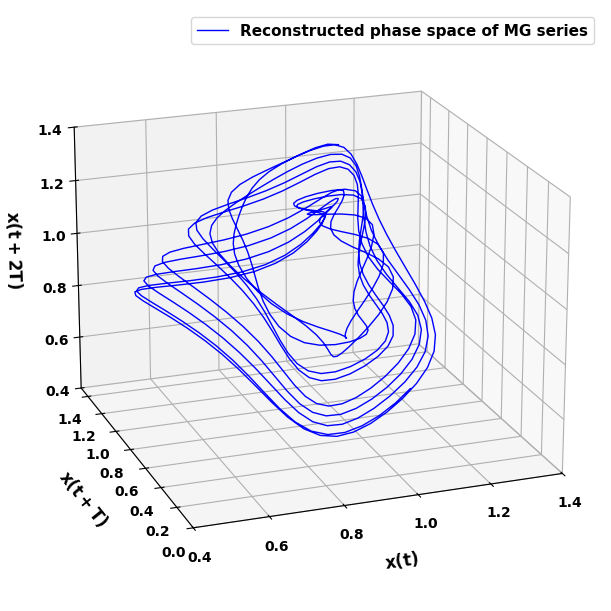

In [3]:
# Plotting the reconstructed phase space trajectory
# 1. Force bold fonts globally for clean academic viewing
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

# 2. Defining x, y, and z axis coordinates for clarity
x1 = y[:500,0]
x2 = y[:500,1]
x3 = y[:500,2]

# 3. Initialize the figure and add a 3D subplot
fig = plt.figure(figsize=(8, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the 3D curve
# 'color' sets the line color, 'lw' sets line width
ax.plot3D(x1, x2, x3, color='blue', lw=1, label=r'Reconstructed phase space of MG series')

# 5. Add bold LaTeX labels and titles
#ax.set_title("3D Space Curve Exploration", fontsize=16, pad=15)
ax.set_xlabel(r'$\mathbf{x(t)}$', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\mathbf{x(t+T)}$', fontsize=12, labelpad=10)
ax.set_zlabel(r'$\mathbf{x(t+2T)}$', fontsize=12, labelpad=10)

ax.set_xlim(0.4,1.4)
ax.set_ylim(0,1.5)
ax.set_zlim(0.4,1.4)

# 6. Make tick marks bold manually
ax.tick_params(axis='both', which='major', labelsize=10)

# Optional: Adjust the viewing perspective angle (elevation, azimuth)
ax.view_init(elev=20, azim=-110)

ax.legend(fontsize=11)
plt.show()

In [4]:
## MLP: Data and definitions
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
## Defining the MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        # Small MLP Architecture
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Input: Number of observables
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), # Optional second layer
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim)  # Output: Task dependent
        )
        
    def forward(self, x):
        return self.network(x)


def predict_single(sample_array, model):
    """
    sample_array: a single reservoir state (or vector)
    """
    model.eval()
    with torch.no_grad():
        # 1. Convert to tensor
        sample_tensor = torch.tensor(sample_array, dtype=torch.float32)
        
        # 2. Add batch dimension if it's a flat 1D array
        if sample_tensor.ndim == 1:
            sample_tensor = sample_tensor.unsqueeze(0)
        
        # 3. Predict
        prediction = model(sample_tensor)
        
        # 4. FIX: Convert the entire tensor to a numpy array and flatten/squeeze it
        # This safely handles 1 output, 3 outputs, or any dimension D.
        return prediction.cpu().numpy().squeeze()
    
## Preparing Training Data
X = y[:-1,:]    #input
Y = y[1:,:]     #target output

# Split data: 80% Training, 20% Validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32)

# Create a dataset and loader for batching
dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# model
model = MLP(input_dim=D, hidden_dim=5, output_dim=D)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [5]:
## Genetic Algorithm : Definitions

# Create Population
import random
rng = np.random.default_rng(seed=42)

def create_population(pop_size, chromosome_length):
    population = []
    for _ in range(pop_size):
        # Generates a list of 228 random 0s and 1s
        chromosome = [random.randint(0, 1) for _ in range(chromosome_length)]
        population.append(chromosome)
    return population

# Parameters
POPULATION_SIZE = 100  # Change this to whatever you need
CHROMOSOME_LENGTH = 228
GENE_LENGTH = 6
FRACTIONAL_BITS = 3
GENES = CHROMOSOME_LENGTH//GENE_LENGTH

# Generate
my_population = create_population(POPULATION_SIZE, CHROMOSOME_LENGTH)


# Decode Population

def decode(chromosome, gene_length=GENE_LENGTH):
    decoded_weights = []
    
    for i in range(0, len(chromosome), gene_length):
        gene_bits = chromosome[i:i+gene_length]
        bit_string = "".join(map(str, gene_bits))
        
        # 1. Convert 6 bits to integer (0 to 63)
        integer_val = int(bit_string, 2)
        
        # 2. Map linearly to [-1.0, 1.0]
        # (integer_val / 63.0) gives a number between 0.0 and 1.0
        # Multiplying by 2 and subtracting 1 shifts it to [-1.0, 1.0]
        weight = -1.0 + (integer_val / 63.0) * 2.0
        
        decoded_weights.append(weight)
        
    return decoded_weights

def set_parameters(chromosome):
    # 1. Decode and reshape into NumPy arrays
    w1 = np.array(decode(chromosome[:15*6])).reshape(3, 5).T
    b1 = np.array(decode(chromosome[15*6:20*6]))
    w2 = np.array(decode(chromosome[20*6:35*6])).reshape(5, 3).T
    b2 = np.array(decode(chromosome[35*6:38*6]))
    # 2. Inject weights without tracking gradients
    with torch.no_grad():
        model.network[0].weight.copy_(torch.tensor(w1, dtype=torch.float32))
        model.network[0].bias.copy_(torch.tensor(b1, dtype=torch.float32))
        
        model.network[4].weight.copy_(torch.tensor(w2, dtype=torch.float32))
        model.network[4].bias.copy_(torch.tensor(b2, dtype=torch.float32))


## Assesing fitness of a chromosome
# chromosome to w1,b1,w2,b2
def fitness(chromosome, model=model, criterion=criterion, X_val_tensor=X_val_tensor, Y_val_tensor=Y_val_tensor):
    # 1. Decode and reshape into NumPy arrays
    w1 = np.array(decode(chromosome[:15*6])).reshape(3, 5).T
    b1 = np.array(decode(chromosome[15*6:20*6]))
    w2 = np.array(decode(chromosome[20*6:35*6])).reshape(5, 3).T
    b2 = np.array(decode(chromosome[35*6:38*6]))

    # 2. Inject weights without tracking gradients
    with torch.no_grad():
        model.network[0].weight.copy_(torch.tensor(w1, dtype=torch.float32))
        model.network[0].bias.copy_(torch.tensor(b1, dtype=torch.float32))
        
        model.network[4].weight.copy_(torch.tensor(w2, dtype=torch.float32))
        model.network[4].bias.copy_(torch.tensor(b2, dtype=torch.float32))

        # 3. Evaluate directly on validation data
        model.eval() 
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, Y_val_tensor)

    # Returning loss (Lower is better for fitness evaluation)
    return val_loss.item()

def tournament_selection(population, fitness_scores, tournament_size=3):
    """
    Selects one winning chromosome using a tournament.
    fitness_scores: a list/array of loss values corresponding to the population.
    """
    # Pick random indices from the population to enter the tournament
    chosen_indices = rng.choice(len(population), size=tournament_size, replace=False)
    
    # Find the index with the MINIMUM loss (best fitness)
    best_index = chosen_indices[np.argmin([fitness_scores[i] for i in chosen_indices])]
    
    return population[best_index]

def crossover(parent1, parent2, gene_length = GENE_LENGTH):
    n_genes = len(parent1)//gene_length
    if rng.uniform() < 0.3:
        return parent1, parent2
    else:
        i = rng.choice(n_genes-1)
        child1 = parent1[:(i+1)*gene_length] + parent2[(i+1)*gene_length:]
        child2 = parent2[:(i+1)*gene_length] + parent1[(i+1)*gene_length:]
        return child1, child2

def mutate(child, mutation_rate=0.01):
    for i in range(len(child)):
        if rng.uniform() < mutation_rate:
            child[i] ^= 1
    return child

In [6]:
## Genetic Algorithm: The Algorithm

# 1. Evaluate the entire population
fitness_scores = [fitness(chrom) for chrom in my_population]

# 2. Track your absolute best individual (Elitism)
best_idx = np.argmin(fitness_scores)
best_chromosome = my_population[best_idx]
best_loss = fitness_scores[best_idx]
print(f"Zeroeth Generation Best Loss: {best_loss:.6f}")

n_iterations=30
for i in range(n_iterations):
    # 3. Breed the next generation
    next_generation = [best_chromosome] # Carry over the best individual automatically

    while len(next_generation) < len(my_population):
        # Select two parents using tournament selection
        parent1 = tournament_selection(my_population, fitness_scores, tournament_size=3)
        parent2 = tournament_selection(my_population, fitness_scores, tournament_size=3)
        
        # Crossover
        child1, child2 = crossover(parent1, parent2) # Implement your crossover logic here
        
        # Mutation
        child1 = mutate(child1) # Implement your mutation logic here
        child2 = mutate(child2)
        
        next_generation.append(child1)
        if len(next_generation) < len(my_population):
            next_generation.append(child2)

    my_population = next_generation
    
    # 1. Evaluate the entire population
    fitness_scores = [fitness(chrom) for chrom in my_population]

    # 2. Track your absolute best individual (Elitism)
    best_idx = np.argmin(fitness_scores)
    best_chromosome = my_population[best_idx]
    best_loss = fitness_scores[best_idx]
    print(f"Generation Best Loss: {best_loss:.6f} at index: {best_idx}")

Zeroeth Generation Best Loss: 0.102928
Generation Best Loss: 0.082887 at index: 56
Generation Best Loss: 0.082887 at index: 0
Generation Best Loss: 0.058971 at index: 29
Generation Best Loss: 0.055606 at index: 99
Generation Best Loss: 0.052676 at index: 68
Generation Best Loss: 0.055747 at index: 64
Generation Best Loss: 0.053404 at index: 4
Generation Best Loss: 0.053995 at index: 77
Generation Best Loss: 0.052298 at index: 80
Generation Best Loss: 0.053067 at index: 0
Generation Best Loss: 0.053036 at index: 45
Generation Best Loss: 0.050958 at index: 69
Generation Best Loss: 0.052013 at index: 63
Generation Best Loss: 0.051031 at index: 24
Generation Best Loss: 0.051031 at index: 0
Generation Best Loss: 0.051031 at index: 0
Generation Best Loss: 0.049976 at index: 23
Generation Best Loss: 0.049976 at index: 0
Generation Best Loss: 0.050166 at index: 5
Generation Best Loss: 0.049501 at index: 54
Generation Best Loss: 0.049501 at index: 0
Generation Best Loss: 0.049492 at index: 56
G

In [7]:
## MLP: Refining the best chromosome using gradient descent

# Hyperparameters
num_epochs = 2000

## SET THE INITIAL WEIGHTS TO THE BEST CHROMOSOME !!!!!!!!!!!!!!!!!!!!!!!!!
set_parameters(my_population[best_idx])

# Train and validate!
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        # 1. Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # 2. Backward pass (the "learning" part)
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights
        
        epoch_loss += loss.item()
    
    # Validation Check
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, Y_val_tensor)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {epoch_loss/len(train_loader):.4f} | Val Loss: {val_loss.item():.4f}")

Epoch 10: Train Loss: 0.0452 | Val Loss: 0.0494
Epoch 20: Train Loss: 0.0454 | Val Loss: 0.0471
Epoch 30: Train Loss: 0.0431 | Val Loss: 0.0436
Epoch 40: Train Loss: 0.0390 | Val Loss: 0.0408
Epoch 50: Train Loss: 0.0357 | Val Loss: 0.0373
Epoch 60: Train Loss: 0.0325 | Val Loss: 0.0335
Epoch 70: Train Loss: 0.0307 | Val Loss: 0.0297
Epoch 80: Train Loss: 0.0272 | Val Loss: 0.0262
Epoch 90: Train Loss: 0.0231 | Val Loss: 0.0235
Epoch 100: Train Loss: 0.0210 | Val Loss: 0.0210
Epoch 110: Train Loss: 0.0191 | Val Loss: 0.0187
Epoch 120: Train Loss: 0.0171 | Val Loss: 0.0165
Epoch 130: Train Loss: 0.0140 | Val Loss: 0.0141
Epoch 140: Train Loss: 0.0110 | Val Loss: 0.0116
Epoch 150: Train Loss: 0.0090 | Val Loss: 0.0092
Epoch 160: Train Loss: 0.0066 | Val Loss: 0.0071
Epoch 170: Train Loss: 0.0049 | Val Loss: 0.0053
Epoch 180: Train Loss: 0.0036 | Val Loss: 0.0041
Epoch 190: Train Loss: 0.0029 | Val Loss: 0.0033
Epoch 200: Train Loss: 0.0024 | Val Loss: 0.0030
Epoch 210: Train Loss: 0.0023

In [8]:
## Evaluation
y_pred = np.zeros([500,D])
y_pred[0,:] = predict_single(Y[-1], model)
for k in range(1,500):
    y_pred[k,:] = predict_single(y_pred[k-1,:],model)

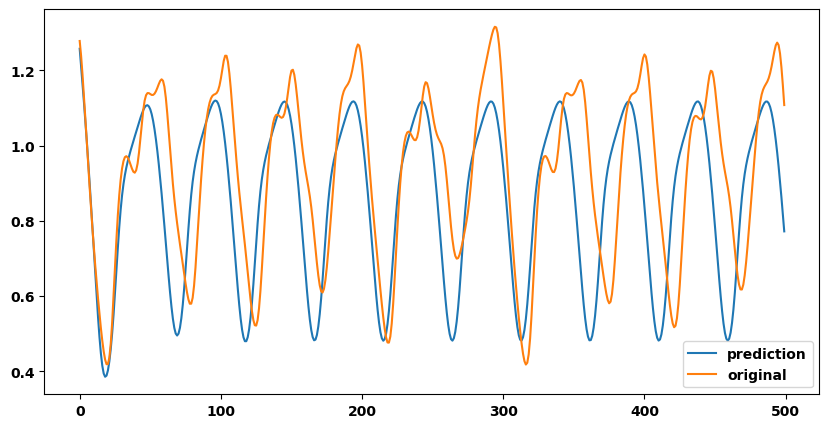

In [9]:
plt.figure(figsize=(10,5))
plt.plot(y_pred[:,D-1],label='prediction')
plt.plot(x[500:],label='original')
plt.legend()

## Rough

In [10]:
import numpy as np

rng = np.random.default_rng()

In [11]:
print(rng.choice([0,4,5,9]))

0
